<a href="https://colab.research.google.com/github/Julian09327/Prueba/blob/Drawing/Estrategys.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
!pip install statsmodels

In [4]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# Paso 1: Descargar datos historicos
tickers = ['^GSPC', '^NDX', 'GC=F', 'BTC-USD']
names = ['SP500', 'NASDAQ100', 'GOLD', 'BTC']

# Modifica estas fechas para cambiar el rango de los datos
data = yf.download(tickers, start='2020-01-01', end='2026-03-10')['Close']

# Renombrar columnas
data.columns = names

# Limpieza
data.dropna(inplace=True)

print("Datos Descargados:\n", data.head())

/tmp/ipykernel_214/1011452665.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start='2020-01-01', end='2026-03-10')['Close']
[*********************100%***********************]  4 of 4 completed

Datos Descargados:
                   SP500    NASDAQ100         GOLD          BTC
Date                                                          
2020-01-02  6985.470215  1524.500000  3257.850098  8872.219727
2020-01-03  7344.884277  1549.199951  3234.850098  8793.900391
2020-01-06  7769.219238  1566.199951  3246.280029  8848.519531
2020-01-07  8163.692383  1571.800049  3237.179932  8846.450195
2020-01-08  8079.862793  1557.400024  3253.050049  8912.370117


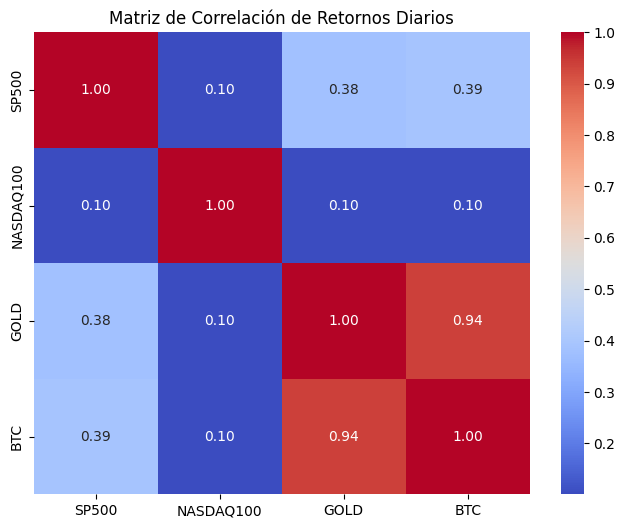

In [5]:
# Paso 2: Calcular retornos diarios
returns = data.pct_change().dropna()

# Paso 3: Matriz de correlación
plt.figure(figsize=(8, 6))
sns.heatmap(returns.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de Correlación de Retornos Diarios")
plt.show()

In [6]:
from ast import For
num_portfolios = 10000
results = np.zeros((3, num_portfolios))
weights_record = []

annual_returns = returns.mean() * 252
cov_matrix_annual = returns.cov() * 252

for i in range(num_portfolios):
  weights = np.random.random(len(names))
  weights /= np.sum(weights)
  weights_record.append(weights)

  port_return = np.dot(weights, annual_returns)
  port_volatility = np.sqrt(np.dot(weights.T, np.dot(cov_matrix_annual, weights)))
  sharpe = port_return / port_volatility

  results[0, i] = port_return
  results[1, i] = port_volatility
  results[2, i] = sharpe

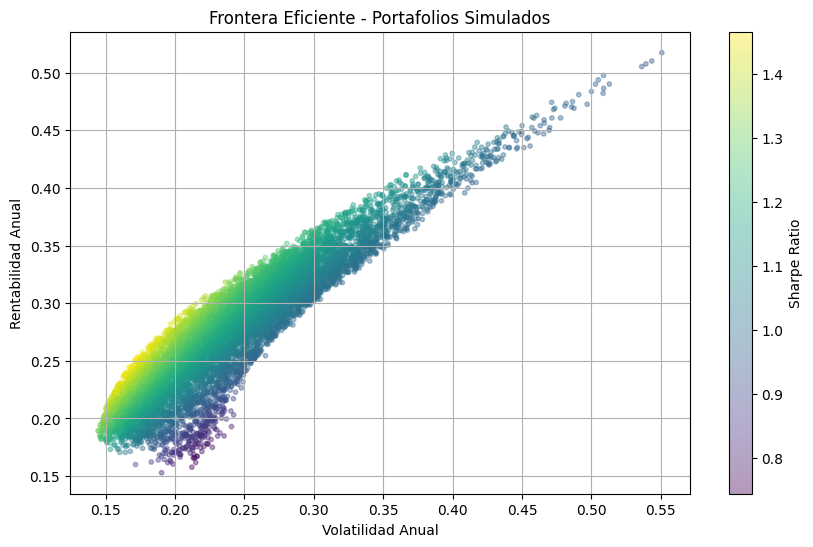

In [7]:
plt.figure(figsize=(10, 6))
plt.scatter(results[1, :], results[0, :], c=results[2, :], cmap='viridis', s=10, alpha=0.4)
plt.xlabel('Volatilidad Anual')
plt.ylabel('Rentabilidad Anual')
plt.title('Frontera Eficiente - Portafolios Simulados')
plt.colorbar(label='Sharpe Ratio')
plt.grid(True)
plt.show()

In [9]:
max_sharpe_idx = results[2].argmax()
opt_weights = weights_record[max_sharpe_idx]

print("\n--- Pesos de Portafolio Óptimo (Sharpe Máximo)---")
opt_weights_series = pd.Series(opt_weights, index=returns.columns)
print(opt_weights_series.apply(lambda x: f"{x*100:.2f}%"))



--- Pesos de Portafolio Óptimo (Sharpe Máximo)---
SP500        12.07%
NASDAQ100    66.85%
GOLD          2.51%
BTC          18.56%
dtype: object


In [10]:
opt_port_returns = returns.dot(opt_weights)

annual_return = np.mean(opt_port_returns) * 252
annual_volatility = np.std(opt_port_returns) * np.sqrt(252)
sharpe_ratio = annual_return / annual_volatility

print("\n--- Estadísticas del Portafolio Óptimo---")
print(f"Rentabilidad Anual: {annual_return:.2%}")
print(f"Volatilidad Anual: {annual_volatility:.2%}")
print(f"Ratio de Sharpe: {sharpe_ratio:.4f}")


--- Estadísticas del Portafolio Óptimo---
Rentabilidad Anual: 25.09%
Volatilidad Anual: 17.10%
Ratio de Sharpe: 1.4672


In [11]:
from re import X
market_returns = returns['SP500']

X = sm.add_constant(market_returns)
model = sm.OLS(opt_port_returns, X).fit()

alpha_daily = model.params['const']
beta = model.params['SP500']
alpha_annual = alpha_daily * 252

print("\n--- Alpha y Beta ---")
print(f"Alpha Diario: {alpha_daily:.6f}")
print(f"Alpha Anualizado: {alpha_annual:.4f} ({alpha_annual*100:.2f}%)")
print(f"Beta frente al S&P 500: {beta:.4f}")


--- Alpha y Beta ---
Alpha Diario: 0.000606
Alpha Anualizado: 0.1528 (15.28%)
Beta frente al S&P 500: 0.1740


In [12]:
VaR_95 = np.percentile(opt_port_returns, 5)
VaR_99 = np.percentile(opt_port_returns, 1)

print("\n--- Value at Risk (VaR) ---")
print(f"VaR 95% diario: {VaR_95:.2%}")
print(f"VaR 99% diario: {VaR_99:.2%}")


--- Value at Risk (VaR) ---
VaR 95% diario: -1.57%
VaR 99% diario: -2.84%


In [13]:
last_date = opt_port_returns.index[-1]
one_year_ago = last_date - pd.DateOffset(years=1)

last_year_returns = opt_port_returns[opt_port_returns.index >= one_year_ago]

cumulative_returns = (1 + last_year_returns).cumprod()
rolling_max = cumulative_returns.cummax()
drawdown = (cumulative_returns - rolling_max) / rolling_max
max_drawdown = drawdown.min()
max_profit = cumulative_returns.max() - 1

print("\n--- Último Año (Profit & Drawdown) ---")
print(f"Máximo Profit en el último año: {max_profit:.2%}")
print(f"Maximo Drawdown en el último año: {max_drawdown:.2%}")


--- Último Año (Profit & Drawdown) ---
Máximo Profit en el último año: 60.36%
Maximo Drawdown en el último año: -10.27%


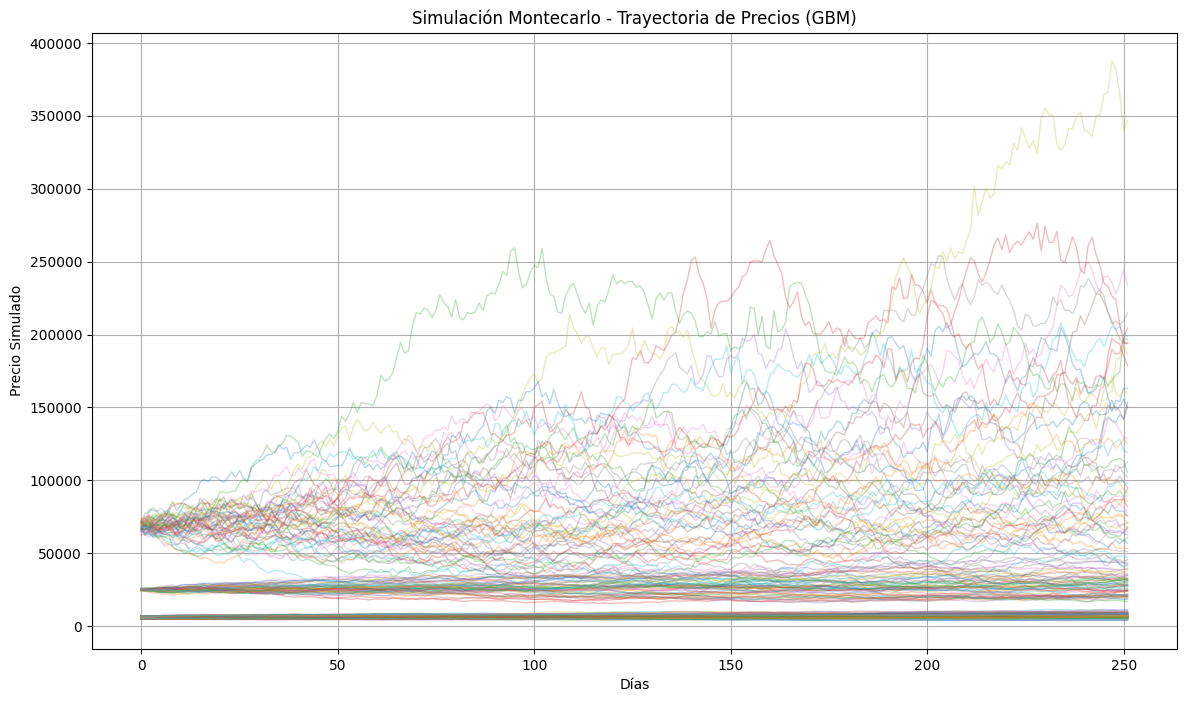

In [14]:
# BLOQUE 11 - Simulación Montecarlo de Precios (Trayectoria por activo)

num_days = 252      # 1 año
num_sims = 50       # número de trayectorias

# Medias y volatilidades diarias
mu = returns.mean()
sigma =returns.std()

plt.figure(figsize=(14, 8))

last_prices = data.iloc[-1]

for asset in data.columns:
  S0 = last_prices[asset]
  drift = mu[asset] - 0.5 * sigma[asset]**2

  simulations = np.zeros((num_days, num_sims))

  for i in range(num_sims):
    daily_shocks = np.random.normal(0, sigma[asset], num_days)
    path = S0 * np.exp(np.cumsum(drift + daily_shocks))
    simulations[:, i] = path

  # Graficar
  plt.plot(simulations, alpha=0.3, linewidth=1)

plt.title("Simulación Montecarlo - Trayectoria de Precios (GBM)")
plt.xlabel("Días")
plt.ylabel("Precio Simulado")
plt.grid(True)
plt.show()

In [41]:
def hurst_exponent(data, max_lag=100):
    # Ensure data is a pandas Series for .diff()
    if isinstance(data, np.ndarray):
        data = pd.Series(data)

    lags = range(2, max_lag)
    tau = []
    for k in lags:
        increments = data.diff(k).dropna().values
        if len(increments) > 0:
            tau.append(np.std(increments))
        else:
            tau.append(np.nan)

    lags_arr = np.array(lags)
    tau_arr = np.array(tau)

    not_nan_indices = ~np.isnan(tau_arr)
    lags_clean = lags_arr[not_nan_indices]
    tau_clean = tau_arr[not_nan_indices]

    positive_tau_indices = (tau_clean > 0)
    lags_positive = lags_clean[positive_tau_indices]
    tau_positive = tau_clean[positive_tau_indices]

    if len(lags_positive) < 2:
        return np.nan # Not enough valid data points

    log_lags = np.log(lags_positive)
    log_tau = np.log(tau_positive)

    poly = np.polyfit(log_lags, log_tau, 1)
    return poly[0]

# Ejemplo de uso
random_walk_data = np.random.randn(1000).cumsum()  # Serie de paseo aleatorio
H = hurst_exponent(random_walk_data)
print(f"Exponente de Hurst: {H:.3f}")

Exponente de Hurst: 0.433


# Exponente de Hurst para Retornos del Portafolio Óptimo

Vamos a calcular el Exponente de Hurst para los retornos diarios del portafolio óptimo y visualizar el proceso de cálculo.

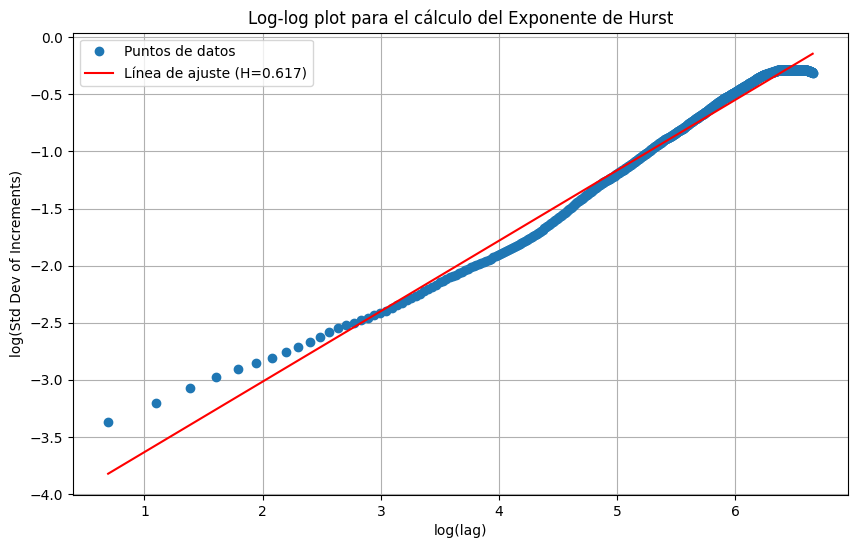


Exponente de Hurst para el Portafolio Óptimo (cumulative): 0.617
Interpretación: La serie de retornos acumulados es *persistente* (tiende a seguir una tendencia).


In [42]:
def hurst_exponent_with_plot(data, max_lag=None):
    if max_lag is None:
        max_lag = int(len(data) / 2) # Use half the data length as max_lag
        if max_lag < 2: # Ensure max_lag is at least 2 for lags range
            max_lag = len(data) - 1 if len(data) > 2 else 2

    # Generate lags explicitly
    lags = [k for k in range(2, max_lag) if k < len(data)]

    tau = []
    for k in lags:
        # Correct calculation of increments using .diff()
        increments = data.diff(k).dropna().values
        if len(increments) > 0:
            std_val = np.std(increments)
            tau.append(std_val)
        else:
            tau.append(np.nan)

    # Convert to numpy arrays for easier filtering
    lags_arr = np.array(lags)
    tau_arr = np.array(tau)

    # Filter out NaNs from tau and corresponding lags
    not_nan_indices = ~np.isnan(tau_arr)
    lags_clean = lags_arr[not_nan_indices]
    tau_clean = tau_arr[not_nan_indices]

    # Filter out non-positive tau values before taking log to avoid RuntimeWarning and -inf
    positive_tau_indices = (tau_clean > 0)
    lags_positive = lags_clean[positive_tau_indices]
    tau_positive = tau_clean[positive_tau_indices]

    if len(lags_positive) < 2:
        print("No hay suficientes datos válidos (después de asegurar tau > 0) para calcular el exponente de Hurst.")
        return None, None, None

    # Now take logs, which should be safe as tau_positive > 0
    log_lags = np.log(lags_positive)
    log_tau = np.log(tau_positive)

    poly = np.polyfit(log_lags, log_tau, 1)
    H = poly[0]

    plt.figure(figsize=(10, 6))
    plt.plot(log_lags, log_tau, 'o', label='Puntos de datos')
    plt.plot(log_lags, poly[0] * log_lags + poly[1], 'r-', label=f'Línea de ajuste (H={H:.3f})')
    plt.title('Log-log plot para el cálculo del Exponente de Hurst')
    plt.xlabel('log(lag)')
    plt.ylabel('log(Std Dev of Increments)')
    plt.legend()
    plt.grid(True)
    plt.show()

    return H, poly[0] * log_lags + poly[1], log_lags

# Calcular y graficar el Exponente de Hurst para los retornos CUMULATIVOS del portafolio óptimo
cumulative_opt_port_returns = (1 + opt_port_returns).cumprod()

H_opt_port, fitted_line, log_lags = hurst_exponent_with_plot(cumulative_opt_port_returns)

if H_opt_port is not None:
    print(f"\nExponente de Hurst para el Portafolio Óptimo (cumulative): {H_opt_port:.3f}")

    if H_opt_port < 0.5:
        print("Interpretación: La serie de retornos acumulados es *anti-persistente* (tiende a revertir a la media).")
    elif H_opt_port == 0.5:
        print("Interpretación: La serie de retornos acumulados sigue un *paseo aleatorio* (no hay correlación de largo plazo).")
    else:
        print("Interpretación: La serie de retornos acumulados es *persistente* (tiende a seguir una tendencia).")

# Comparación del Exponente de Hurst para las Series Individuales

Ahora, vamos a calcular el Exponente de Hurst para cada una de las series que componen el portafolio, basándonos en sus retornos acumulados. Esto nos permitirá comparar su comportamiento con el del portafolio óptimo.


--- Exponente de Hurst para SP500 ---


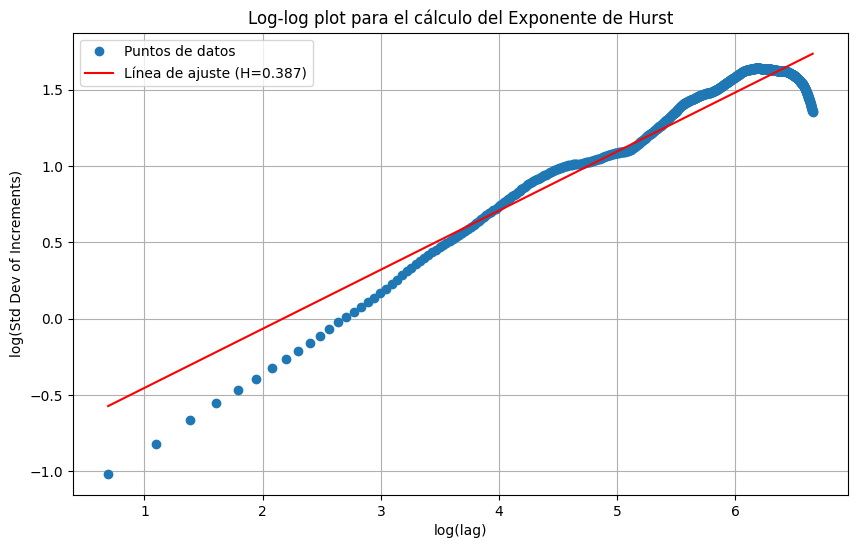

Exponente de Hurst para SP500 (cumulative): 0.387
Interpretación: La serie de retornos acumulados es *anti-persistente* (tiende a revertir a la media).

--- Exponente de Hurst para NASDAQ100 ---


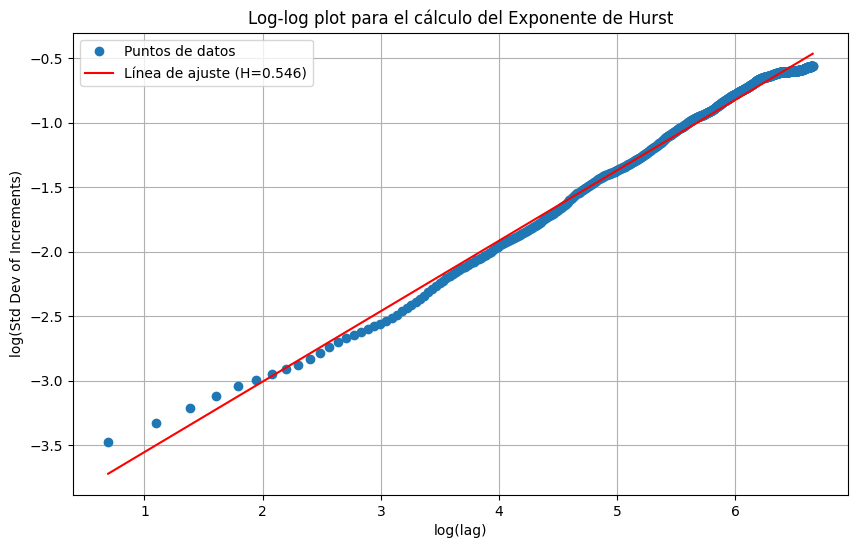

Exponente de Hurst para NASDAQ100 (cumulative): 0.546
Interpretación: La serie de retornos acumulados es *persistente* (tiende a seguir una tendencia).

--- Exponente de Hurst para GOLD ---


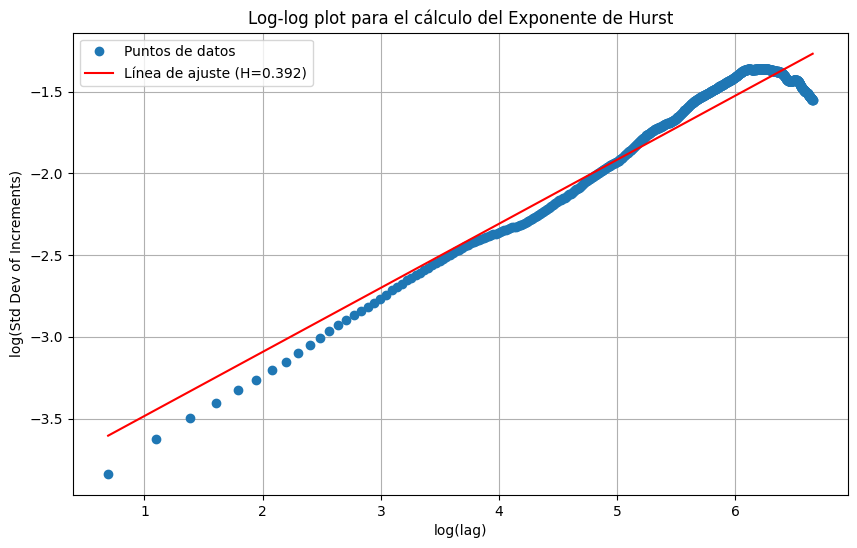

Exponente de Hurst para GOLD (cumulative): 0.392
Interpretación: La serie de retornos acumulados es *anti-persistente* (tiende a revertir a la media).

--- Exponente de Hurst para BTC ---


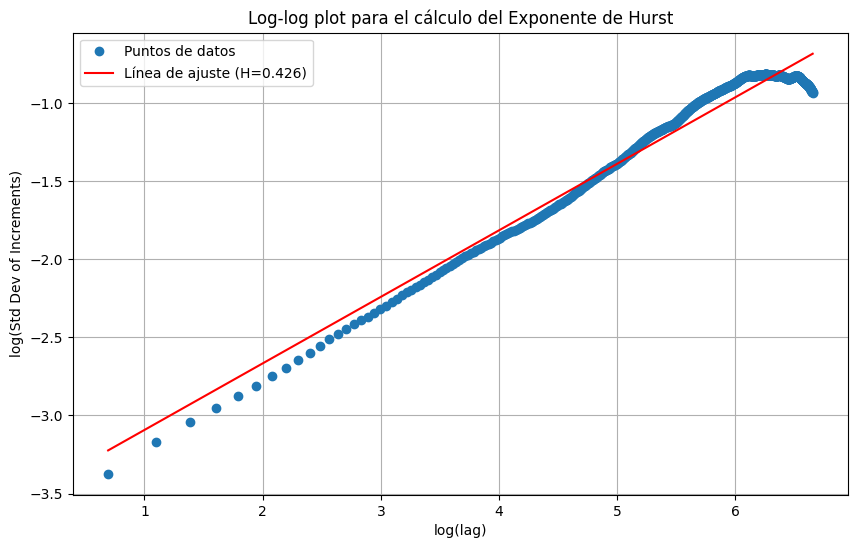

Exponente de Hurst para BTC (cumulative): 0.426
Interpretación: La serie de retornos acumulados es *anti-persistente* (tiende a revertir a la media).

--- Resumen de Exponentes de Hurst ---
Portafolio Óptimo (cumulative): 0.617
SP500 (cumulative): 0.387
NASDAQ100 (cumulative): 0.546
GOLD (cumulative): 0.392
BTC (cumulative): 0.426


In [43]:
hurst_exponents_individual = {}

for asset_name in names:
    print(f"\n--- Exponente de Hurst para {asset_name} ---")
    individual_returns = returns[asset_name]
    cumulative_individual_returns = (1 + individual_returns).cumprod()

    H_individual, _, _ = hurst_exponent_with_plot(cumulative_individual_returns)

    if H_individual is not None:
        hurst_exponents_individual[asset_name] = H_individual
        print(f"Exponente de Hurst para {asset_name} (cumulative): {H_individual:.3f}")

        if H_individual < 0.5:
            print("Interpretación: La serie de retornos acumulados es *anti-persistente* (tiende a revertir a la media).")
        elif H_individual == 0.5:
            print("Interpretación: La serie de retornos acumulados sigue un *paseo aleatorio* (no hay correlación de largo plazo).")
        else:
            print("Interpretación: La serie de retornos acumulados es *persistente* (tiende a seguir una tendencia).")

print("\n--- Resumen de Exponentes de Hurst ---")
print(f"Portafolio Óptimo (cumulative): {H_opt_port:.3f}")
for asset, H_val in hurst_exponents_individual.items():
    print(f"{asset} (cumulative): {H_val:.3f}")

# Resumen General del Cuaderno: Análisis de Portafolio y Riesgo

Este cuaderno realiza un análisis exhaustivo de portafolios, enfocado en la optimización riesgo-rendimiento y la caracterización de los activos financieros. A continuación, se detalla cada `Paso` y su propósito:

*   **Paso 1: Descarga de Datos Históricos (`yf.download`)**
    *   **Propósito:** Obtener precios históricos de cierre de los activos seleccionados (SP500, NASDAQ100, GOLD, BTC) de Yahoo Finance. Estos datos son la base para todos los análisis posteriores.
    *   **Qué mide:** Los precios de los activos a lo largo del tiempo.
    *   **Cómo funciona:** Utiliza la librería `yfinance` para consultar y descargar datos directamente.

*   **Paso 2: Cálculo de Retornos Diarios (`data.pct_change()`)**
    *   **Propósito:** Transformar los precios diarios en retornos diarios porcentuales. Los retornos son fundamentales para el análisis financiero ya que representan las ganancias o pérdidas relativas de un activo.
    *   **Qué mide:** El cambio porcentual diario en el precio de cada activo.
    *   **Cómo funciona:** Calcula el cambio porcentual entre cada día de negociación.

*   **Paso 3: Matriz de Correlación (`sns.heatmap(returns.corr())`)**
    *   **Propósito:** Visualizar la relación lineal entre los retornos de los diferentes activos. Es crucial para entender cómo se mueven los activos entre sí y es un insumo clave para la diversificación.
    *   **Qué mide:** El coeficiente de correlación entre cada par de activos. Valores cercanos a 1 indican que se mueven en la misma dirección, -1 en direcciones opuestas, y 0 que no tienen relación lineal.
    *   **Cómo funciona:** Calcula la matriz de correlación de Pearson y la visualiza con un mapa de calor.

*   **Simulación Montecarlo de Portafolios (Frontera Eficiente)**
    *   **Propósito:** Simular miles de combinaciones de pesos para crear portafolios aleatorios y evaluar su rendimiento y volatilidad. El objetivo es identificar la **Frontera Eficiente**, que muestra los portafolios que ofrecen el mayor rendimiento para un nivel de riesgo dado, o el menor riesgo para un rendimiento dado.
    *   **Qué mide:** La rentabilidad anualizada y la volatilidad anualizada (riesgo) de cada portafolio simulado, así como su **Sharpe Ratio** (rentabilidad ajustada por riesgo).
    *   **Cómo funciona:** Asigna pesos aleatorios a los activos, calcula la rentabilidad y volatilidad del portafolio, y repite este proceso miles de veces. Luego, grafica estos puntos (volatilidad vs. rendimiento) codificados por el Sharpe Ratio.

*   **Portafolio Óptimo (Sharpe Máximo)**
    *   **Propósito:** Identificar el portafolio dentro de la frontera eficiente que ofrece el **Sharpe Ratio más alto**. Este es el portafolio que, según la teoría moderna de portafolios, ofrece la mejor compensación entre riesgo y rendimiento.
    *   **Qué mide:** Los pesos (porcentajes de inversión) de cada activo en el portafolio con el Sharpe Ratio más alto.
    *   **Cómo funciona:** Encuentra el punto con el Sharpe Ratio máximo en los resultados de la simulación Montecarlo.

*   **Estadísticas del Portafolio Óptimo (Rentabilidad, Volatilidad, Sharpe Ratio)**
    *   **Propósito:** Cuantificar el rendimiento y riesgo específicos del portafolio óptimo.
    *   **Qué mide:** La rentabilidad anualizada, la volatilidad anualizada y el Sharpe Ratio del portafolio óptimo.
    *   **Cómo funciona:** Utiliza los pesos del portafolio óptimo para calcular sus retornos históricos y luego anualiza sus estadísticas.

*   **Alpha y Beta (`statsmodels.OLS`)**
    *   **Propósito:** Evaluar el rendimiento del portafolio óptimo en relación con un índice de mercado (en este caso, el SP500).
    *   **Qué mide:**
        *   **Beta:** La sensibilidad del portafolio a los movimientos del mercado. Una Beta de 1 significa que se mueve con el mercado, >1 es más volátil, <1 es menos volátil.
        *   **Alpha:** El rendimiento excedente del portafolio en comparación con lo que se esperaría dado su Beta y el rendimiento del mercado. Un Alpha positivo indica que el portafolio ha superado al mercado ajustado por riesgo.
    *   **Cómo funciona:** Realiza una regresión lineal (OLS) de los retornos del portafolio óptimo contra los retornos del mercado (SP500).

*   **Value at Risk (VaR) (`np.percentile`)**
    *   **Propósito:** Estimar la pérdida potencial máxima de un portafolio en un período de tiempo dado y con un cierto nivel de confianza.
    *   **Qué mide:** El VaR 95% y 99% diario. Por ejemplo, un VaR 95% de -1.58% significa que hay un 5% de probabilidad de que la pérdida diaria del portafolio sea igual o mayor al 1.58%.
    *   **Cómo funciona:** Calcula el percentil de los retornos diarios del portafolio.

*   **Máximo Drawdown y Profit en el Último Año (`cumulative_returns`, `rolling_max`)**
    *   **Propósito:** Evaluar el riesgo de caída y el crecimiento máximo del portafolio en un período reciente.
    *   **Qué mide:**
        *   **Máximo Drawdown:** La mayor caída porcentual desde un pico de valor hasta un mínimo antes de recuperar un nuevo pico. Es una medida clave del riesgo de cola.
        *   **Máximo Profit:** La mayor ganancia acumulada en el período.
    *   **Cómo funciona:** Calcula los retornos acumulados y el máximo histórico de estos para determinar la caída desde el pico.

*   **Simulación Montecarlo de Precios (GBM) (`np.random.normal`, `np.exp`)**
    *   **Propósito:** Proyectar posibles trayectorias futuras de los precios de los activos individuales basándose en un modelo de movimiento browniano geométrico (GBM).
    *   **Qué mide:** Múltiples escenarios de precios futuros para cada activo.
    *   **Cómo funciona:** Simula pasos aleatorios (shocks) aplicando la media y volatilidad histórica de cada activo, generando diferentes caminos de precios.

*   **Exponente de Hurst (`hurst_exponent_with_plot`)**
    *   **Propósito:** Medir la "memoria" o persistencia de una serie temporal. Ayuda a entender si una serie tiende a revertir a la media, a seguir una tendencia, o a comportarse de manera aleatoria.
    *   **Qué mide:** Un valor H:
        *   **H < 0.5 (Anti-persistente/Mean-reverting):** La serie tiende a revertir a su media. Si sube hoy, es probable que baje mañana.
        *   **H = 0.5 (Paseo Aleatorio):** Los movimientos futuros son independientes de los pasados. No hay memoria.
        *   **H > 0.5 (Persistente/Trend-following):** La serie tiende a seguir una tendencia. Si sube hoy, es probable que siga subiendo.
    *   **Cómo funciona:** Se basa en la relación entre el rango rescalado de una serie de tiempo y su número de observaciones. Se grafica en una escala log-log para determinar la pendiente, que es el valor de H.

# Estadísticas Descriptivas de los Datos Descargados

A continuación, se presentan las estadísticas descriptivas para los datos de precios descargados (`data`) y los retornos diarios (`returns`). Esto te dará una idea rápida de la distribución central, dispersión y forma de tus datos.

In [80]:
print("\n--- Estadísticas Descriptivas de los Precios --- ")
display(data.describe())

print("\n--- Estadísticas Descriptivas de los Retornos Diarios ---")
display(returns.describe())


--- Estadísticas Descriptivas de los Precios --- 


,SP500,NASDAQ100,GOLD,BTC
count,1553.000000,1553.000000,1553.000000,1553.000000
mean,48100.993049,2269.659623,4651.191982,15833.045934
std,31481.431767,781.324728,1084.995596,4602.959508
min,4970.788086,1477.300049,2237.399902,6994.290039
25%,22760.109375,1797.400024,3916.639893,12302.480469
50%,41243.832031,1925.000000,4401.459961,14909.259766
75%,66710.156250,2489.899902,5503.410156,19423.070312
max,124752.531250,5318.399902,6978.600098,26119.849609



--- Estadísticas Descriptivas de los Retornos Diarios ---


,SP500,NASDAQ100,GOLD,BTC
count,1552.000000,1552.000000,1552.000000,1552.000000
mean,0.002235,0.000843,0.000559,0.000795
std,0.038758,0.011474,0.013054,0.016026
min,-0.371695,-0.113662,-0.119841,-0.121932
25%,-0.015976,-0.004461,-0.004824,-0.006907
50%,0.000744,0.001080,0.000912,0.001468
75%,0.020237,0.006892,0.006744,0.009136
max,0.211097,0.060833,0.095154,0.120223


## Partes Modificables del Cuaderno y su Propósito

Este cuaderno está diseñado para ser flexible y permitirte experimentar con diferentes configuraciones. Aquí te detallo las partes principales que puedes modificar y el impacto de cada cambio:

1.  **Activos y Rango de Fechas (Celda `23kPUeHkot9u`)**
    *   **Variables a modificar:** `tickers`, `names`, `start`, `end`.
    *   **Propósito:** Aquí defines qué activos financieros quieres analizar y el período histórico de los datos. Cambiar estas variables te permite:
        *   **Analizar diferentes activos:** Si te interesan otras acciones, criptomonedas, materias primas o índices, simplemente reemplaza los símbolos (`tickers`).
        *   **Ajustar el horizonte temporal:** Puedes estudiar el comportamiento de los activos en diferentes ciclos de mercado (por ejemplo, solo durante mercados alcistas, bajistas o periodos de alta volatilidad) o para temporalidades más cortas/largas.
    *   **Con qué fin:** Esto es fundamental para adaptar el análisis a tus intereses específicos y a la disponibilidad de datos de los activos que operas en tus temporalidades de ICT (diaria, 4h, 1h, 15min).

2.  **Número de Portafolios Simulados (Celda `WuwBU-GIyDey`)**
    *   **Variables a modificar:** `num_portfolios`.
    *   **Propósito:** Controla la cantidad de portafolios aleatorios que se generan para construir la Frontera Eficiente. Un mayor número de portafolios te dará una representación más densa y precisa de la frontera.
    *   **Con qué fin:** Si buscas una optimización muy fina del portafolio o tus resultados iniciales parecen muy dispersos, puedes aumentar este número. Sin embargo, ten en cuenta que un valor muy alto incrementará el tiempo de ejecución.

3.  **Simulación Montecarlo de Precios (Celda `TaQpbDg0E3XZ`)**
    *   **Variables a modificar:** `num_days`, `num_sims`.
    *   **Propósito:** Estas variables controlan la duración de la proyección y la cantidad de trayectorias futuras simuladas para cada activo.
    *   **Con qué fin:**
        *   **`num_days`:** Te permite proyectar los precios para diferentes períodos (ej., 252 días para un año de trading, o menos para proyecciones a corto plazo).
        *   **`num_sims`:** Un mayor número de simulaciones te dará un abanico más amplio de posibles resultados, aunque también aumentará el tiempo de ejecución. Es útil para evaluar la robustez de las proyecciones.

4.  **Exponente de Hurst (`max_lag` en `hurst_exponent_with_plot` en celda `c793b9a8`)**
    *   **Variables a modificar:** `max_lag`.
    *   **Propósito:** `max_lag` define el número máximo de períodos de tiempo para los cuales se calcularán las diferencias para el Exponente de Hurst. Afecta la longitud de la "memoria" que se está evaluando en la serie.
    *   **Con qué fin:** Experimentar con `max_lag` puede darte diferentes perspectivas sobre la persistencia o anti-persistencia de la serie en distintos horizontes temporales. Un `max_lag` más grande considera una memoria más larga, mientras que uno más pequeño se enfoca en el corto plazo. Asegúrate de que `max_lag` no sea demasiado grande en relación con la longitud total de tus datos para evitar errores.

Estas son las principales palancas que puedes ajustar para personalizar el análisis según tus necesidades. Recuerda que después de modificar alguna de estas celdas, deberás ejecutar las celdas subsiguientes para que los cambios se reflejen en los resultados.

## 1. Importar Librerías y Definir Parámetros Iniciales

Primero, importamos las librerías necesarias y definimos los tickers de los activos (Oro y Plata), así como las temporalidades que te interesan. También definimos la zona horaria de Bogotá.

In [75]:
import yfinance as yf
import numpy as np
import pandas as pd
import pytz
from datetime import datetime, timedelta

# --- Parámetros Configurables ---

tickers_to_analyze = {
    'Gold': {'ticker': 'GC=F', 'enabled': True},
    'PLATA': {'ticker': 'SI=F', 'enabled': False} # Ejemplo: Plata desactivada
}

# Define las temporalidades y un multiplicador de desviación estándar para la detección de anomalías.
# Un multiplicador más alto requiere una anomalía más extrema para ser detectada.
# Puedes ajustar estos valores según tu tolerancia al riesgo y el comportamiento del mercado.
intervals_and_thresholds = {
    '1d': {'yf_interval': '1d', 'resample_period': None, 'std_multiplier': 3.0, 'days_history': 365*3, 'enabled': False},
    '1h': {'yf_interval': '1h', 'resample_period': None, 'std_multiplier': 2.5, 'days_history': 7, 'enabled': True},
    '15m': {'yf_interval': '15m', 'resample_period': None, 'std_multiplier': 2.5, 'days_history': 10, 'enabled': True},
    '5m': {'yf_interval': '5m', 'resample_period': None, 'std_multiplier': 2.0, 'days_history': 3, 'enabled': False}
}

bogota_tz = pytz.timezone('America/Bogota')

print("Parámetros iniciales cargados.")

Parámetros iniciales cargados.


## 2. Función para Obtener Datos en Tiempo Real y Detectar Anomalías

Esta es la función principal que:

*   Descarga datos históricos hasta el momento actual en GMT-5.
*   Remuestrea los datos si es necesario (ej. para 4h).
*   Calcula los rendimientos logarítmicos.
*   Calcula el promedio móvil y la desviación estándar móvil para establecer umbrales dinámicos.
*   Identifica puntos que superan estos umbrales como anomalías.
*   Clasifica las anomalías como "Compra" o "Venta" y las convierte a la zona horaria GMT-5.

In [76]:
def detect_anomalies_realtime(
    display_asset_name, # Nuevo parámetro para el nombre a mostrar
    ticker_symbol,
    interval_info,
    end_datetime_gmt5,
    window_size=20 # Ventana para promedio móvil y desviación estándar móvil
):
    yf_interval = interval_info['yf_interval']
    resample_period = interval_info['resample_period']
    std_multiplier = interval_info['std_multiplier']
    days_history = interval_info['days_history']

    # Calcular start_datetime_gmt5 basado en days_history
    start_datetime_gmt5 = end_datetime_gmt5 - timedelta(days=days_history)

    # Convertir a objetos datetime en UTC para yfinance
    start_utc_dt = start_datetime_gmt5.astimezone(pytz.utc)
    end_utc_dt = end_datetime_gmt5.astimezone(pytz.utc)

    print(f"\nDescargando {ticker_symbol} para intervalo {yf_interval} desde {start_utc_dt} hasta {end_utc_dt}...")

    # Descargar datos
    data = yf.download(ticker_symbol, start=start_utc_dt, end=end_utc_dt, interval=yf_interval)

    if data.empty:
        print(f"No se encontraron datos para {ticker_symbol} en el intervalo {yf_interval} para el período especificado. Prueba con un historial más corto para temporalidades intradía.")
        return pd.DataFrame()

    # Si los datos vienen con 'Datetime' en lugar de 'Date', renombrar para consistencia
    if 'Datetime' in data.columns: # Para intradía, yfinance a veces devuelve 'Datetime'
        data.index.name = 'Datetime'
        data = data.rename_axis('Date') # Convertir el nombre del índice a 'Date' para consistencia

    # Remuestrear si es necesario (ej. para 4h desde 1h)
    if resample_period:
        print(f"Remuestreando datos de {yf_interval} a {resample_period}...")
        data = data['Close'].resample(resample_period).ohlc().dropna()
        # Necesitamos la columna 'close' para calcular los retornos
        if 'close' not in data.columns:
            data = data.rename(columns={'Close': 'close'}) # Asegurar que la columna de cierre se llame 'close'

    # Asegurar que el índice esté en zona horaria
    if data.index.tz is None:
        # Asumir que yfinance devuelve datos en UTC si no hay tz
        data.index = data.index.tz_localize(pytz.utc)
    else:
        # Convertir a UTC si ya tiene tz
        data.index = data.index.tz_convert(pytz.utc)

    # Calcular rendimientos logarítmicos
    if 'Close' in data.columns:
        log_returns = np.log(data['Close'] / data['Close'].shift(1)).dropna()
    elif 'close' in data.columns: # Para datos remuestreados o intradía, la columna puede ser 'close'
        log_returns = np.log(data['close'] / data['close'].shift(1)).dropna()
    else:
        print(f"Columna de cierre no encontrada en los datos de {ticker_symbol} para el intervalo {yf_interval}. Columnas disponibles: {data.columns.tolist()}")
        return pd.DataFrame()

    # Calcular promedio móvil y desviación estándar móvil de los retornos
    rolling_mean = log_returns.rolling(window=window_size).mean()
    rolling_std = log_returns.rolling(window=window_size).std()

    # Calcular bandas de control
    upper_bound = rolling_mean + std_multiplier * rolling_std
    lower_bound = rolling_mean - std_multiplier * rolling_std

    # Detectar anomalías (puntos fuera de N desviaciones estándar)
    anomalies = log_returns[
        (log_returns > upper_bound) |
        (log_returns < lower_bound)
    ].dropna()

    # --- Visualización de Anomalías ---
    plt.figure(figsize=(14, 7))
    plt.plot(log_returns.index, log_returns, label='Rendimientos Logarítmicos', alpha=0.7)
    plt.plot(rolling_mean.index, rolling_mean, color='orange', label=f'Media Móvil ({window_size})')
    plt.plot(upper_bound.index, upper_bound, color='red', linestyle='--', label=f'+{std_multiplier} Std Dev (Umbral Superior)')
    plt.plot(lower_bound.index, lower_bound, color='red', linestyle='--', label=f'-{std_multiplier} Std Dev (Umbral Inferior)')

    # Marcar anomalías de compra (Alza Extrema)
    buy_anomalies = anomalies[anomalies > 0]
    if not buy_anomalies.empty:
        plt.scatter(buy_anomalies.index, buy_anomalies, color='green', s=100, marker='^', label='Alza Extrema (Compra)', zorder=5)

    # Marcar anomalías de venta (Caída Extrema)
    sell_anomalies = anomalies[anomalies < 0]
    if not sell_anomalies.empty:
        plt.scatter(sell_anomalies.index, sell_anomalies, color='purple', s=100, marker='v', label='Caída Extrema (Venta)', zorder=5)

    plt.title(f'Detección de Anomalías para {display_asset_name} en {yf_interval + (f" ({resample_period})" if resample_period else "")}') # Usar display_asset_name aquí
    plt.xlabel('Fecha/Hora (UTC)')
    plt.ylabel('Rendimiento Logarítmico')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    # --- Fin de Visualización ---


    if anomalies.empty:
        print(f"No se detectaron anomalías significativas para {display_asset_name} en el intervalo {yf_interval}.") # Usar display_asset_name aquí
        return pd.DataFrame()

    # Preparar resultados de anomalías
    num_anomalies = len(anomalies)
    anomalies_df = pd.DataFrame({
        'Ticker': [display_asset_name] * num_anomalies, # Usar display_asset_name aquí
        'Intervalo': [yf_interval + (f' ({resample_period})' if resample_period else '')] * num_anomalies,
        'Fecha/Hora (UTC)': anomalies.index.tolist(),
        'Rendimiento Logarítmico': anomalies.values.tolist(),
        'Tipo de Anomalía': np.where(anomalies > 0, 'Posible Compra', 'Posible Venta').tolist()
    })

    # Convertir a zona horaria GMT-5 (Bogotá)
    anomalies_df['Fecha/Hora (GMT-5 Bogotá)'] = anomalies_df['Fecha/Hora (UTC)'].dt.tz_convert(bogota_tz)
    anomalies_df = anomalies_df.drop(columns=['Fecha/Hora (UTC)'])
    anomalies_df = anomalies_df.set_index('Fecha/Hora (GMT-5 Bogotá)').sort_index()

    print(f"Anomalías detectadas para {display_asset_name} en el intervalo {yf_interval}:") # Usar display_asset_name aquí
    display(anomalies_df)
    return anomalies_df

## 3. Ejecutar el Detector de Anomalías

Aquí ejecutamos la función para cada activo y temporalidad definidos. La fecha de finalización (`end_datetime_gmt5`) se establece automáticamente a la fecha y hora actuales en la zona horaria de Bogotá. Se recopilarán todas las anomalías en un solo DataFrame.

/tmp/ipykernel_214/4031163308.py:23: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker_symbol, start=start_utc_dt, end=end_utc_dt, interval=yf_interval)
[*********************100%***********************]  1 of 1 completed

Omitiendo Gold (GC=F) en temporalidad 1d (desactivado).
Analizando Gold (GC=F) en temporalidad 1h...

Descargando GC=F para intervalo 1h desde 2026-03-08 05:57:47.131565+00:00 hasta 2026-03-15 05:57:47.131565+00:00...


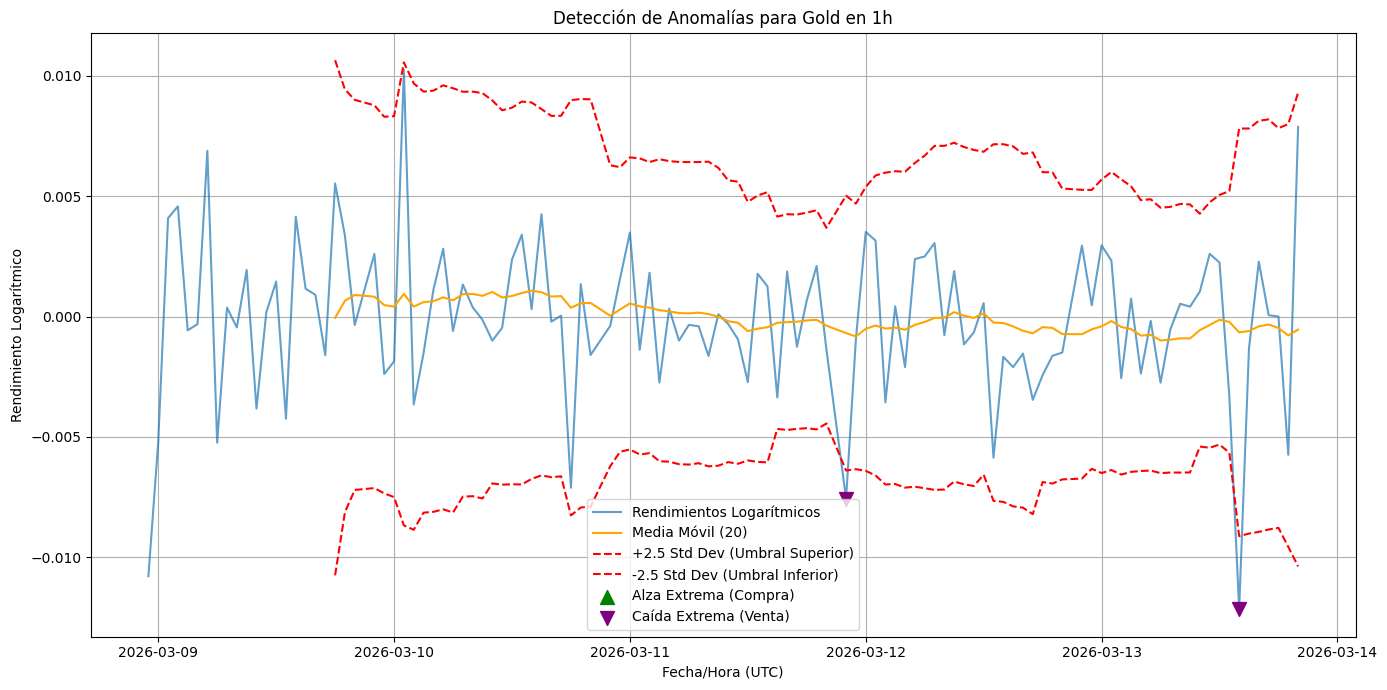

Anomalías detectadas para Gold en el intervalo 1h:


,Ticker,Intervalo,Rendimiento Logarítmico,Tipo de Anomalía
Fecha/Hora (GMT-5 Bogotá),,,,
2026-03-11 17:00:00-05:00,Gold,1h,[-0.007571192026658496],[Posible Venta]
2026-03-13 09:00:00-05:00,Gold,1h,[-0.012153872338947972],[Posible Venta]


/tmp/ipykernel_214/4031163308.py:23: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker_symbol, start=start_utc_dt, end=end_utc_dt, interval=yf_interval)
[*********************100%***********************]  1 of 1 completed

Analizando Gold (GC=F) en temporalidad 15m...

Descargando GC=F para intervalo 15m desde 2026-03-05 05:57:47.131565+00:00 hasta 2026-03-15 05:57:47.131565+00:00...


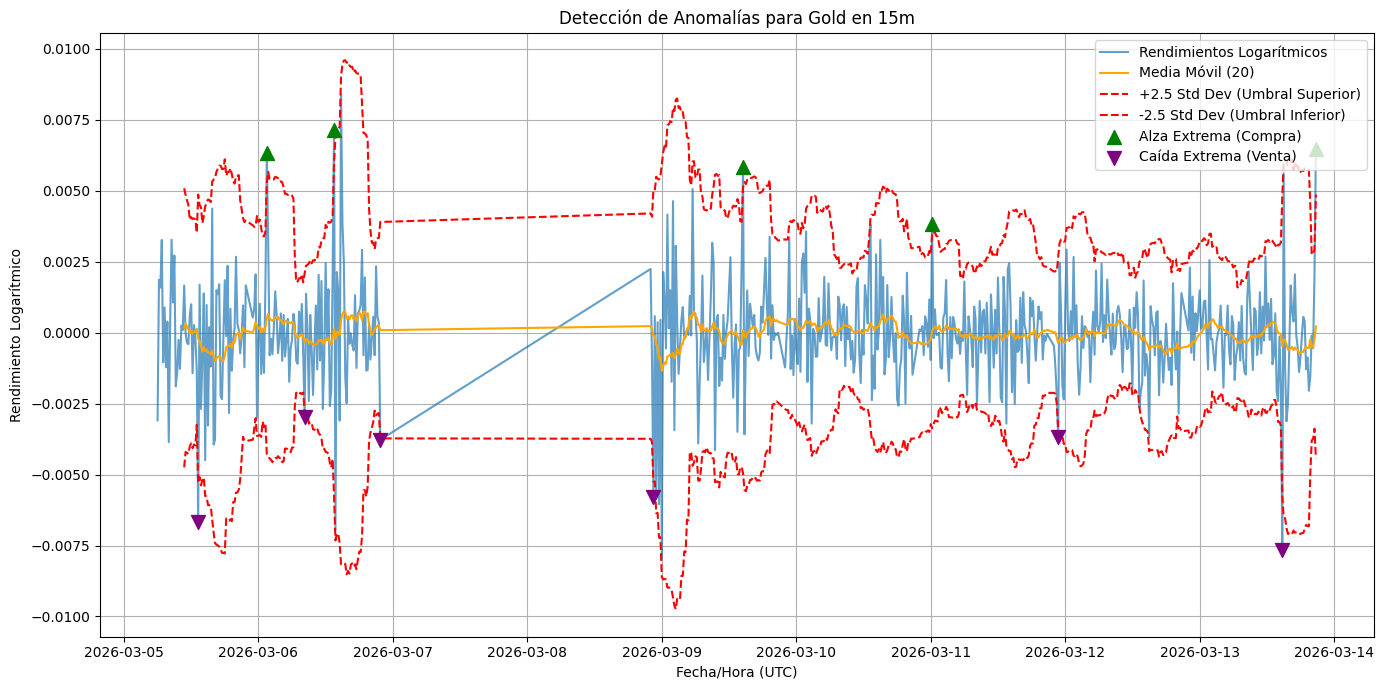

Anomalías detectadas para Gold en el intervalo 15m:


,Ticker,Intervalo,Rendimiento Logarítmico,Tipo de Anomalía
Fecha/Hora (GMT-5 Bogotá),,,,
2026-03-05 08:15:00-05:00,Gold,15m,[-0.006661797822429048],[Posible Venta]
2026-03-05 20:30:00-05:00,Gold,15m,[0.0063210796243920704],[Posible Compra]
2026-03-06 03:15:00-05:00,Gold,15m,[-0.0029707630460481713],[Posible Venta]
2026-03-06 08:30:00-05:00,Gold,15m,[0.00716097941225911],[Posible Compra]
2026-03-06 16:45:00-05:00,Gold,15m,[-0.0037728956252948928],[Posible Venta]
2026-03-08 17:30:00-05:00,Gold,15m,[-0.0058053153802601195],[Posible Venta]
2026-03-09 09:30:00-05:00,Gold,15m,[0.0058362493681390175],[Posible Compra]
2026-03-10 19:15:00-05:00,Gold,15m,[0.0038196737138454393],[Posible Compra]
2026-03-11 17:45:00-05:00,Gold,15m,[-0.0036862468686256734],[Posible Venta]


Omitiendo Gold (GC=F) en temporalidad 5m (desactivado).
Omitiendo PLATA (desactivado).

--- Resumen de TODAS las Anomalías Detectadas ---


,Ticker,Intervalo,Rendimiento Logarítmico,Tipo de Anomalía
Fecha/Hora (GMT-5 Bogotá),,,,
2026-03-05 08:15:00-05:00,Gold,15m,[-0.006661797822429048],[Posible Venta]
2026-03-05 20:30:00-05:00,Gold,15m,[0.0063210796243920704],[Posible Compra]
2026-03-06 03:15:00-05:00,Gold,15m,[-0.0029707630460481713],[Posible Venta]
2026-03-06 08:30:00-05:00,Gold,15m,[0.00716097941225911],[Posible Compra]
2026-03-06 16:45:00-05:00,Gold,15m,[-0.0037728956252948928],[Posible Venta]
2026-03-08 17:30:00-05:00,Gold,15m,[-0.0058053153802601195],[Posible Venta]
2026-03-09 09:30:00-05:00,Gold,15m,[0.0058362493681390175],[Posible Compra]
2026-03-10 19:15:00-05:00,Gold,15m,[0.0038196737138454393],[Posible Compra]
2026-03-11 17:00:00-05:00,Gold,1h,[-0.007571192026658496],[Posible Venta]


In [77]:
all_anomalies = []

# Obtener la fecha y hora actual en la zona horaria de Bogotá
end_datetime_gmt5 = datetime.now(bogota_tz)

for asset_name, asset_info in tickers_to_analyze.items():
    if asset_info.get('enabled', True): # Solo analizar si el activo está habilitado
        ticker_symbol = asset_info['ticker']
        for interval_name, interval_info in intervals_and_thresholds.items():
            if interval_info.get('enabled', True): # Solo ejecutar si 'enabled' es True o no está definido (por defecto True)
                print(f"Analizando {asset_name} ({ticker_symbol}) en temporalidad {interval_name}...")
                anomalies = detect_anomalies_realtime(asset_name, ticker_symbol, interval_info, end_datetime_gmt5) # Pasar asset_name
                if not anomalies.empty:
                    all_anomalies.append(anomalies)
            else:
                print(f"Omitiendo {asset_name} ({ticker_symbol}) en temporalidad {interval_name} (desactivado).")
    else:
        print(f"Omitiendo {asset_name} (desactivado).")

if all_anomalies:
    final_anomalies_df = pd.concat(all_anomalies)
    final_anomalies_df = final_anomalies_df.sort_index()
    print("\n--- Resumen de TODAS las Anomalías Detectadas ---")
    display(final_anomalies_df)
else:
    print("\nNo se detectaron anomalías en ninguna de las temporalidades y activos configurados.")

## 4. Cómo utilizar esta información en tu Análisis Técnico (ICT)

La detección de anomalías no reemplaza tu análisis ICT, sino que lo complementa. Aquí te sugiero cómo puedes integrar esta información:

*   **Confirmación de Rupturas/Quiebres de Estructura (BOS/CHOCH):** Si detectas una anomalía de "Alza Extrema" o "Caída Extrema", esto podría validar un BOS o CHOCH que estés observando en esa temporalidad. Una anomalía de gran magnitud sugiere una fuerte inyección o salida de liquidez.

*   **Identificación de Zonas de Liquidez/POIs:** Las anomalías a menudo ocurren en puntos donde hay una alta actividad (toma de liquidez, reacción a un Order Block, etc.). Utiliza las anomalías para identificar estas zonas de interés (POIs) en tus gráficos. Una "Caída Extrema" en un Order Block alcista, por ejemplo, podría ser una manipulación antes de una subida (wick a la baja), o una fuerte ruptura a la baja.

*   **Validación de Bloques de Órdenes (Order Blocks) y Brechas de Valor Justo (FVG):** Una anomalía de "Alza Extrema" que sale de un Order Block alcista o un FVG alcista podría confirmar su validez. Lo mismo para los escenarios bajistas. Presta atención a si la anomalía *llena* o *rompe* estas estructuras.

*   **Entradas de Reversión (Reversal Entries):** Si estás esperando una reversión en un punto clave de tu análisis ICT (ej. un Supply/Demand Zone o un Breaker Block), una anomalía de "Caída Extrema" seguida de una rápida recuperación (o viceversa) podría ser una señal temprana de que la reversión está en marcha.

*   **Gestión de Riesgos:** Una anomalía inesperada y fuerte en tu contra (ej. una "Caída Extrema" cuando esperas una subida) podría ser una señal para reevaluar tu posición o ajustar tus stops.

*   **Ajuste de Umbrales por Temporalidad:** Como notaste, hemos ajustado los `std_multiplier` (multiplicadores de desviación estándar). Esto significa que en temporalidades más bajas (5m, 15m), el "filtro" para una anomalía es un poco menos estricto (multiplicadores más pequeños), permitiendo que más movimientos significativos, que son comunes en el Day Trading, sean capturados. En temporalidades más altas (1d, 4h), el filtro es más estricto, para señalar solo movimientos realmente fuera de lo común.

**Importante para tu flujo de trabajo:**

1.  **Ejecución:** Cada vez que quieras ver las anomalías actuales, simplemente ejecuta la última celda (`Ejecutar el Detector de Anomalías`). Esto buscará los datos hasta el momento presente.
2.  **Visualización:** Una vez que tengas las anomalías, ve a tus gráficos en TradingView o tu plataforma, busca el activo y la temporalidad indicados, y ubica la `Fecha/Hora (GMT-5 Bogotá)` para ver exactamente dónde ocurrió la anomalía. Luego, analiza qué Price Action se dio en ese punto.
3.  **Refinamiento:** Experimenta con los `std_multiplier` en la sección de "Parámetros Configurables" para encontrar los umbrales que mejor se adapten a tu estilo de trading y a la sensibilidad que buscas en la detección de anomalías.